Creating Graphs to compare Perceived Crime and Actually Crime across 3 force areas

In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
crime_data = pd.read_csv('yorkshire_crime_2024.csv')
perception_data = pd.read_csv('Perceptions_Data_Yorkshire.csv')

In [3]:
crime_data.info()
perception_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12195 entries, 0 to 12194
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   force_name  12195 non-null  object
 1   month       12195 non-null  object
 2   category    12195 non-null  object
dtypes: object(3)
memory usage: 285.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Year              336 non-null    int64 
 1   Age               336 non-null    object
 2   Characteristic    336 non-null    object
 3   Estimate          336 non-null    object
 4   MeasurementLabel  336 non-null    object
 5   CrimeCategory     288 non-null    object
dtypes: int64(1), object(5)
memory usage: 15.9+ KB


In [4]:
# Crime data is counted as a number of crimes per 1000 people
# Perception data is a percentage of people concerned about crime
# We want to compare the two datasets to see if there is a correlation between the number of crimes and the perception of crime
# Datasets have no common coloumns, and we want to protect the perception data by age group for a more detailed analysis
# We ideally want columns for the 3 police foreces with the crime count shown as a percentage to match the perception data


In [5]:
# Convert the 'Estimate' column to numeric by removing the '%' and dividing by 100
perception_data['Estimate'] = perception_data['Estimate'].str.rstrip('%').astype(float)

# Group by 'Age' and 'CrimeCategory' and sum the 'Estimate' values
grouped_data = perception_data.groupby(['Age', 'MeasurementLabel', 'CrimeCategory'])['Estimate'].sum().reset_index()

# Display the grouped data
print(grouped_data)


    Age                                   MeasurementLabel  \
0   16+      Perceived high level of anti-social behaviour   
1   16+  Perceived problem with  people using or dealin...   
2   16+  Perceived problem with abandoned or burnt out ...   
3   16+  Perceived problem with litter or rubbish in th...   
4   16+  Perceived problem with noisy neighbours in the...   
..  ...                                                ...   
91  75+  Perceived problem with vandalism and graffiti ...   
92  75+                             Worried about burglary   
93  75+                            Worried about car crime   
94  75+                                Worried about fraud   
95  75+                        Worried about violent crime   

            CrimeCategory  Estimate  
0   anti-social-behaviour     32.73  
1                   drugs     77.96  
2   anti-social-behaviour      7.41  
3   anti-social-behaviour     95.36  
4   anti-social-behaviour     26.88  
..                    ...  

In [6]:
# remove 16+ rows as double counting
grouped_data = grouped_data.drop(grouped_data[grouped_data['Age'] == '16+'].index)

In [7]:
# Grouped data csv
grouped_data.to_csv('Perceptions_by_Age.csv')

In [8]:
perception_data = perception_data.drop(perception_data[perception_data['Age'] == '16+'].index)


In [12]:
grouped_data2 = perception_data.groupby(['MeasurementLabel', 'CrimeCategory'])['Estimate'].mean()
grouped_data2.head()

MeasurementLabel                                                         CrimeCategory        
Perceived high level of anti-social behaviour                            anti-social-behaviour    11.299048
Perceived problem with  people using or dealing drugs in the local area  drugs                    26.546667
Perceived problem with abandoned or burnt out cars in the local area     anti-social-behaviour     2.325714
Perceived problem with litter or rubbish in the local area               anti-social-behaviour    32.329524
Perceived problem with noisy neighbours in the local area                anti-social-behaviour     9.174286
Name: Estimate, dtype: float64

In [13]:
grouped_data2.to_csv('OverallMeanPerception.csv')

In [15]:
grouped_data

,Age,MeasurementLabel,CrimeCategory,Estimate
12,16-24,Perceived high level of anti-social behaviour,anti-social-behaviour,93.26
13,16-24,Perceived problem with people using or dealin...,drugs,153.16
14,16-24,Perceived problem with abandoned or burnt out ...,anti-social-behaviour,0.69
15,16-24,Perceived problem with litter or rubbish in th...,anti-social-behaviour,174.11
16,16-24,Perceived problem with noisy neighbours in the...,anti-social-behaviour,69.45
...,...,...,...,...
91,75+,Perceived problem with vandalism and graffiti ...,criminal-damage-arson,9.60
92,75+,Worried about burglary,burglary,23.05
93,75+,Worried about car crime,vehicle-crime,19.20
94,75+,Worried about fraud,other-crime,59.28


In [14]:
grouped_data.mean

<bound method DataFrame.mean of       Age                                   MeasurementLabel  \
12  16-24      Perceived high level of anti-social behaviour   
13  16-24  Perceived problem with  people using or dealin...   
14  16-24  Perceived problem with abandoned or burnt out ...   
15  16-24  Perceived problem with litter or rubbish in th...   
16  16-24  Perceived problem with noisy neighbours in the...   
..    ...                                                ...   
91    75+  Perceived problem with vandalism and graffiti ...   
92    75+                             Worried about burglary   
93    75+                            Worried about car crime   
94    75+                                Worried about fraud   
95    75+                        Worried about violent crime   

            CrimeCategory  Estimate  
12  anti-social-behaviour     93.26  
13                  drugs    153.16  
14  anti-social-behaviour      0.69  
15  anti-social-behaviour    174.11  
16  anti-

In [16]:
# Import required library
import pandas as pd

# Step 1: Load the CSV data
# Assuming the CSV file is in the same directory as your notebook
# If not, provide the full path to the file
data = pd.read_csv('Perceptions_Data_Yorkshire.csv')

# Step 2: Filter for 2024 data
data_2024 = data[data['Year'] == 2024]

# Step 3: Convert 'Estimate' to numeric by removing the '%' sign and converting to float
data_2024['Estimate'] = data_2024['Estimate'].str.rstrip('%').astype(float)

# Step 4: Group by Age and CrimeCategory, and calculate the mean Estimate
# Using mean to consolidate multiple entries while keeping percentages valid
grouped_data = data_2024.groupby(['Age', 'CrimeCategory'])['Estimate'].mean().reset_index()

# Step 5: Pivot the data to create a table with Age as rows and CrimeCategory as columns
pivot_table = grouped_data.pivot(index='Age', columns='CrimeCategory', values='Estimate')

# Round the estimates to 2 decimal places for clarity
pivot_table = pivot_table.round(2)

# Step 6: Display the full table
print("Average Estimates (%) by Age and Crime Category:")
display(pivot_table)  # Use display() for better formatting in Jupyter Notebook

# Step 7: Extract specific result for 16-24 year-olds and drug crime
drug_crime_16_24 = pivot_table.loc['16-24', 'drugs']
print(f"\nPercentage of 16-24 year-olds who believe drug crime is happening: {drug_crime_16_24}%")

Average Estimates (%) by Age and Crime Category:


CrimeCategory,anti-social-behaviour,burglary,criminal-damage-arson,drugs,other-crime,public-order,vehicle-crime,violent-crime
Age,,,,,,,,
16+,13.28,9.13,12.58,25.99,18.05,11.09,7.42,7.02
16-24,25.32,6.92,31.40,51.05,0.85,22.59,4.37,5.83
25-34,15.46,10.00,12.48,25.64,12.12,14.31,5.01,9.88
35-44,13.40,10.04,15.68,23.19,18.53,10.42,15.37,5.77
45-54,16.30,5.72,14.41,38.35,20.94,17.23,7.80,6.99
55-64,9.36,11.57,6.16,18.75,24.94,5.56,5.53,7.52
65-74,9.00,10.63,7.70,16.87,26.13,6.37,6.14,7.93
75+,5.35,7.68,3.20,11.97,19.76,2.96,6.40,3.49



Percentage of 16-24 year-olds who believe drug crime is happening: 51.05%


C:\Users\ickle\AppData\Local\Temp\ipykernel_37124\2600282530.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perception_2024['Estimate'] = perception_2024['Estimate'].str.rstrip('%').astype(float)


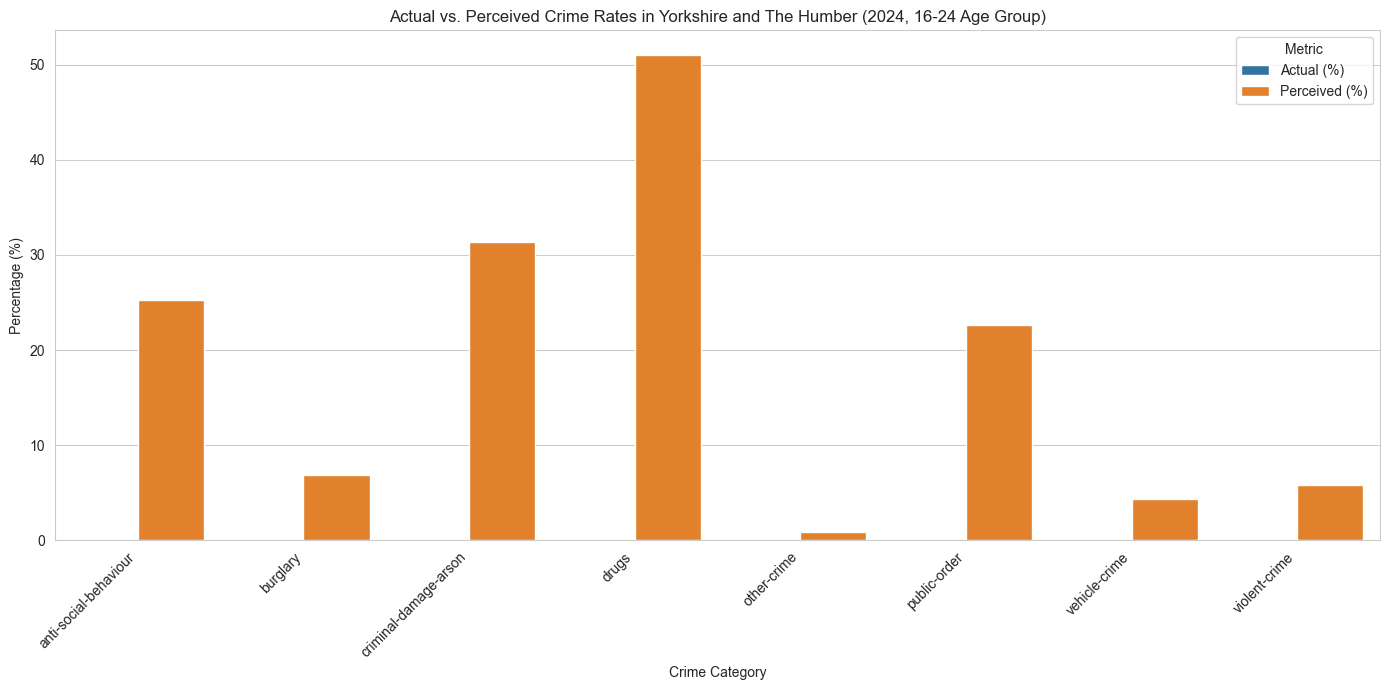


Comparison of Actual and Perceived Crime Rates (16-24 Age Group, %):


,category,actual_percentage,perceived_percentage
0,anti-social-behaviour,0.01,25.32
1,burglary,0.01,6.92
2,criminal-damage-arson,0.02,31.40
3,drugs,0.01,51.05
4,other-crime,0.01,0.85
5,public-order,0.02,22.59
6,vehicle-crime,0.01,4.37
7,violent-crime,0.09,5.83


In [25]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Process the actual crime data (yorkshire_crime_2024.csv)
# Load the actual crime data
actual_crime_data = pd.read_csv('yorkshire_crime_2024.csv')

# Count the number of crimes per category
crime_counts = actual_crime_data.groupby('category').size().reset_index(name='count')

# Population of Yorkshire and The Humber (approx. 5.5 million)
population = 5_500_000
pop_per_thousand = population / 1000  # 5,500

# Calculate crime rate per 1,000 population
crime_counts['rate_per_1000'] = crime_counts['count'] / pop_per_thousand

# Convert rate per 1,000 to percentage (1 per 1,000 = 0.1%)
crime_counts['actual_percentage'] = crime_counts['rate_per_1000'] * 0.1

# Step 2: Process the perceived crime data (Perceptions_Data_Yorkshire.csv)
# Load the perception data
perception_data = pd.read_csv('Perceptions_Data_Yorkshire.csv')

# Filter for 2024 and 16-24 age group
perception_2024 = perception_data[(perception_data['Year'] == 2024) & (perception_data['Age'] == '16-24')]

# Convert 'Estimate' to numeric by removing '%' and converting to float
perception_2024['Estimate'] = perception_2024['Estimate'].str.rstrip('%').astype(float)

# Combine anti-social-behaviour sub-categories by averaging their estimates
# Handle NaN values in the 'CrimeCategory' column
asb_categories = perception_2024[perception_2024['CrimeCategory'].fillna('').str.contains('anti-social-behaviour')]['CrimeCategory'].unique()
asb_data = perception_2024[perception_2024['CrimeCategory'].isin(asb_categories)]
asb_avg = asb_data.groupby('Age')['Estimate'].mean().reset_index()
asb_avg['CrimeCategory'] = 'anti-social-behaviour'

# Filter out anti-social-behaviour sub-categories and append the combined one
# Handle NaN values in the 'CrimeCategory' column before applying the ~ operator
other_categories = perception_2024[~perception_2024['CrimeCategory'].fillna('').str.contains('anti-social-behaviour')]
perception_cleaned = pd.concat([other_categories, asb_avg], ignore_index=True)

# Filter for shared categories
shared_categories = ['anti-social-behaviour', 'burglary', 'criminal-damage-arson', 'drugs', 'other-crime', 'public-order', 'vehicle-crime', 'violent-crime']
perception_cleaned = perception_cleaned[perception_cleaned['CrimeCategory'].isin(shared_categories)]

# Group by CrimeCategory to ensure single estimate per category
perception_grouped = perception_cleaned.groupby('CrimeCategory')['Estimate'].mean().reset_index()
perception_grouped.columns = ['category', 'perceived_percentage']

# Step 3: Merge actual and perceived data
comparison_data = pd.merge(crime_counts[['category', 'actual_percentage']], perception_grouped, on='category', how='inner')

# Step 4: Prepare data for visualization (melt for side-by-side bars)
comparison_melted = pd.melt(comparison_data, id_vars=['category'], 
                            value_vars=['actual_percentage', 'perceived_percentage'],
                            var_name='metric', value_name='percentage')
comparison_melted['metric'] = comparison_melted['metric'].map({
    'actual_percentage': 'Actual (%)',
    'perceived_percentage': 'Perceived (%)'
})

# Step 5: Visualize the comparison
# Set seaborn style
sns.set_style("whitegrid")

# Create side-by-side bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x='category', y='percentage', hue='metric', data=comparison_melted)
plt.title('Actual vs. Perceived Crime Rates in Yorkshire and The Humber (2024, 16-24 Age Group)')
plt.xlabel('Crime Category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()

# Save the plot
plt.savefig('crime_comparison_all_categories_percentage.png')
plt.show()

# Step 6: Display the comparison table
print("\nComparison of Actual and Perceived Crime Rates (16-24 Age Group, %):")
comparison_data['actual_percentage'] = comparison_data['actual_percentage'].round(2)
comparison_data['perceived_percentage'] = comparison_data['perceived_percentage'].round(2)
display(comparison_data[['category', 'actual_percentage', 'perceived_percentage']])

In [ ]:
#work out antisocial behaviour as a pie chart


C:\Users\ickle\AppData\Local\Temp\ipykernel_37124\1614166605.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perception_2024['Estimate'] = perception_2024['Estimate'].str.rstrip('%').astype(float)


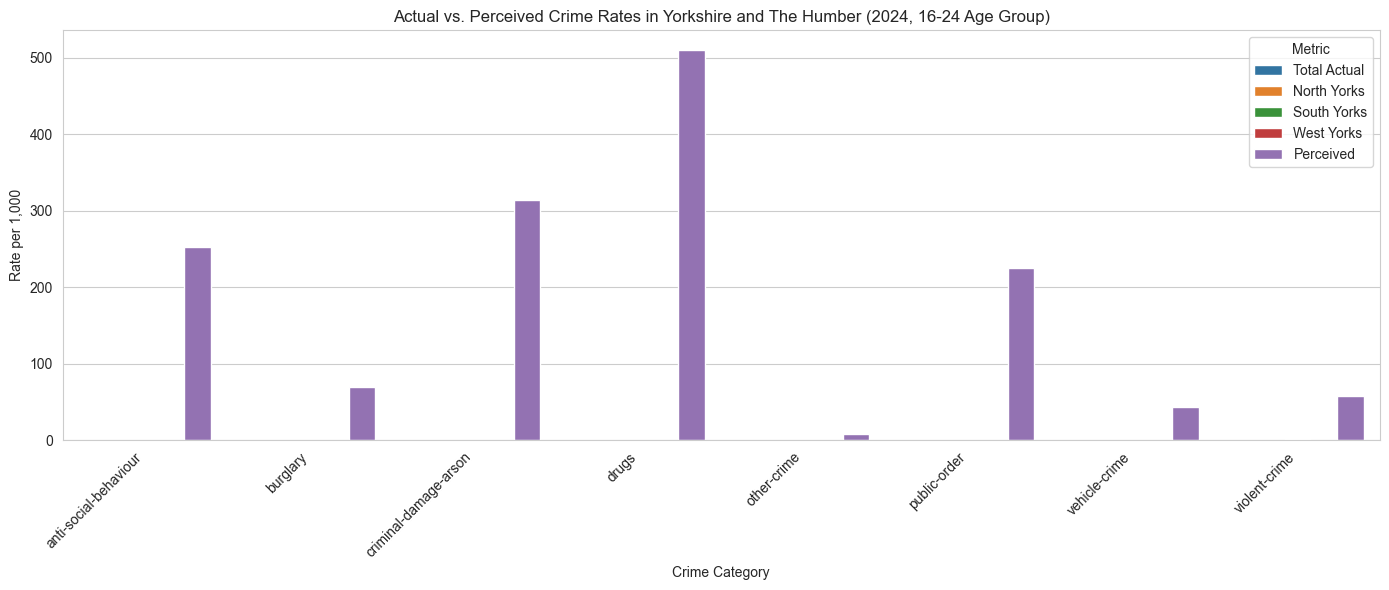


Comparison of Actual and Perceived Crime Rates (16-24 Age Group, per 1,000):


,category,actual_per_1000,North Yorkshire,South Yorkshire,West Yorkshire,perceived_per_1000
0,anti-social-behaviour,0.09,0.11,0.00,0.12,253.15
1,burglary,0.14,0.00,0.49,0.03,69.17
2,criminal-damage-arson,0.16,0.01,0.49,0.09,314.00
3,drugs,0.15,0.01,0.41,0.10,510.53
4,other-crime,0.11,0.01,0.16,0.16,8.53
5,public-order,0.20,0.01,0.56,0.13,225.90
6,vehicle-crime,0.14,0.00,0.43,0.07,43.67
7,violent-crime,0.87,0.05,2.29,0.64,58.33


In [28]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Process the actual crime data (yorkshire_crime_2024.csv)
# Load the actual crime data
actual_crime_data = pd.read_csv('yorkshire_crime_2024.csv')

# Total population of Yorkshire and The Humber (approx. 5.5 million)
total_population = 5_500_000
pop_per_thousand = total_population / 1000  # 5,500

# Approximate population per force (adjust if exact figures available)
force_populations = {
    'South Yorkshire': 1_400_000 / 1000,  # 1.4M
    'West Yorkshire': 2_300_000 / 1000,   # 2.3M
    'North Yorkshire': 1_800_000 / 1000   # 1.8M
}

# Calculate total crimes and rate per 1,000 per category
crime_counts_total = actual_crime_data.groupby('category').size().reset_index(name='total_count')
crime_counts_total['actual_per_1000'] = crime_counts_total['total_count'] / pop_per_thousand

# Calculate crimes per force and rate per 1,000 per force
crime_by_force = actual_crime_data.groupby(['force_name', 'category']).size().reset_index(name='count')
for force, pop in force_populations.items():
    crime_by_force.loc[crime_by_force['force_name'] == force, 'rate_per_1000'] = crime_by_force['count'] / pop

# Pivot for visualization
crime_pivot = crime_by_force.pivot(index='category', columns='force_name', values='rate_per_1000').reset_index()
crime_pivot = crime_pivot.fillna(0)
crime_pivot = pd.merge(crime_pivot, crime_counts_total[['category', 'actual_per_1000']], on='category')

# Step 2: Process the perceived crime data (Perceptions_Data_Yorkshire.csv)
# Load the perception data
perception_data = pd.read_csv('Perceptions_Data_Yorkshire.csv')

# Filter for 2024 and 16-24 age group
perception_2024 = perception_data[(perception_data['Year'] == 2024) & (perception_data['Age'] == '16-24')]

# Convert 'Estimate' to numeric by removing '%' and converting to float
perception_2024['Estimate'] = perception_2024['Estimate'].str.rstrip('%').astype(float)

# Combine anti-social-behaviour sub-categories by averaging their estimates
asb_categories = perception_2024[perception_2024['CrimeCategory'].fillna('').str.contains('anti-social-behaviour')]['CrimeCategory'].unique()
asb_data = perception_2024[perception_2024['CrimeCategory'].fillna('').isin(asb_categories)]
asb_avg = asb_data.groupby('Age')['Estimate'].mean().reset_index()
asb_avg['CrimeCategory'] = 'anti-social-behaviour'

# Filter out anti-social-behaviour sub-categories and append the combined one
other_categories = perception_2024[~perception_2024['CrimeCategory'].fillna('').str.contains('anti-social-behaviour')]
perception_cleaned = pd.concat([other_categories, asb_avg], ignore_index=True)

# Filter for shared categories
shared_categories = ['anti-social-behaviour', 'burglary', 'criminal-damage-arson', 'drugs', 'other-crime', 'public-order', 'vehicle-crime', 'violent-crime']
perception_cleaned = perception_cleaned[perception_cleaned['CrimeCategory'].isin(shared_categories)]

# Group by CrimeCategory to ensure single estimate per category
perception_grouped = perception_cleaned.groupby('CrimeCategory')['Estimate'].mean().reset_index()
perception_grouped.columns = ['category', 'perceived_percentage']

# Convert perceived percentage to per 1,000 (1% = 10 per 1,000)
perception_grouped['perceived_per_1000'] = perception_grouped['perceived_percentage'] * 10

# Step 3: Merge actual and perceived data
comparison_data = pd.merge(crime_pivot, perception_grouped[['category', 'perceived_per_1000']], on='category', how='inner')

# Step 4: Prepare data for visualization
comparison_melted = pd.melt(comparison_data, id_vars=['category'], 
                            value_vars=['actual_per_1000', 'North Yorkshire', 'South Yorkshire', 'West Yorkshire', 'perceived_per_1000'],
                            var_name='metric', value_name='rate_per_1000')
comparison_melted['metric'] = comparison_melted['metric'].map({
    'actual_per_1000': 'Total Actual',
    'North Yorkshire': 'North Yorks',
    'South Yorkshire': 'South Yorks',
    'West Yorkshire': 'West Yorks',
    'perceived_per_1000': 'Perceived'
})

# Step 5: Visualize the comparison
# Set seaborn style
sns.set_style("whitegrid")

# Create grouped bar plot
plt.figure(figsize=(14, 6))
sns.barplot(x='category', y='rate_per_1000', hue='metric', data=comparison_melted)
plt.title('Actual vs. Perceived Crime Rates in Yorkshire and The Humber (2024, 16-24 Age Group)')
plt.xlabel('Crime Category')
plt.ylabel('Rate per 1,000')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()

# Save the plot
plt.savefig('crime_comparison_force_split.png')
plt.show()

# Step 6: Display the comparison table
print("\nComparison of Actual and Perceived Crime Rates (16-24 Age Group, per 1,000):")
comparison_data['actual_per_1000'] = comparison_data['actual_per_1000'].round(2)
comparison_data['North Yorkshire'] = comparison_data['North Yorkshire'].round(2)
comparison_data['South Yorkshire'] = comparison_data['South Yorkshire'].round(2)
comparison_data['West Yorkshire'] = comparison_data['West Yorkshire'].round(2)
comparison_data['perceived_per_1000'] = comparison_data['perceived_per_1000'].round(2)
display(comparison_data[['category', 'actual_per_1000', 'North Yorkshire', 'South Yorkshire', 'West Yorkshire', 'perceived_per_1000']])

C:\Users\ickle\AppData\Local\Temp\ipykernel_37124\2130558673.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perception_2024['Estimate'] = perception_2024['Estimate'].str.rstrip('%').astype(float)


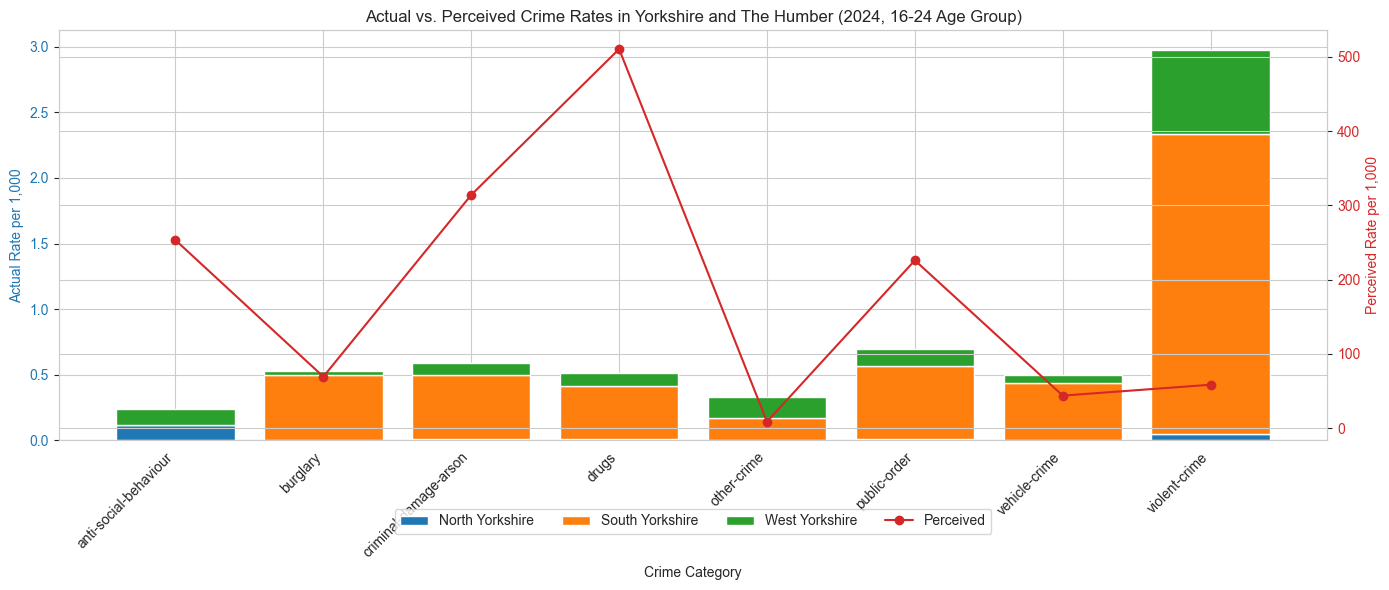


Comparison of Actual and Perceived Crime Rates (16-24 Age Group, per 1,000):


,category,actual_per_1000,North Yorkshire,South Yorkshire,West Yorkshire,perceived_per_1000
0,anti-social-behaviour,0.09,0.11,0.00,0.12,253.15
1,burglary,0.14,0.00,0.49,0.03,69.17
2,criminal-damage-arson,0.16,0.01,0.49,0.09,314.00
3,drugs,0.15,0.01,0.41,0.10,510.53
4,other-crime,0.11,0.01,0.16,0.16,8.53
5,public-order,0.20,0.01,0.56,0.13,225.90
6,vehicle-crime,0.14,0.00,0.43,0.07,43.67
7,violent-crime,0.87,0.05,2.29,0.64,58.33


In [31]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Process the actual crime data (yorkshire_crime_2024.csv)
# Load the actual crime data
actual_crime_data = pd.read_csv('yorkshire_crime_2024.csv')

# Total population of Yorkshire and The Humber (approx. 5.5 million)
total_population = 5_500_000
pop_per_thousand = total_population / 1000  # 5,500

# Approximate population per force (adjust if exact figures available)
force_populations = {
    'South Yorkshire': 1_400_000 / 1000,  # 1.4M
    'West Yorkshire': 2_300_000 / 1000,   # 2.3M
    'North Yorkshire': 1_800_000 / 1000   # 1.8M
}

# Calculate total crimes and rate per 1,000 per category
crime_counts_total = actual_crime_data.groupby('category').size().reset_index(name='total_count')
crime_counts_total['actual_per_1000'] = crime_counts_total['total_count'] / pop_per_thousand

# Calculate crimes per force and rate per 1,000 per force
crime_by_force = actual_crime_data.groupby(['force_name', 'category']).size().reset_index(name='count')
for force, pop in force_populations.items():
    crime_by_force.loc[crime_by_force['force_name'] == force, 'rate_per_1000'] = crime_by_force['count'] / pop

# Pivot for stacked bars
crime_pivot = crime_by_force.pivot(index='category', columns='force_name', values='rate_per_1000').reset_index()
crime_pivot = crime_pivot.fillna(0)
crime_pivot = pd.merge(crime_pivot, crime_counts_total[['category', 'actual_per_1000']], on='category')

# Step 2: Process the perceived crime data (Perceptions_Data_Yorkshire.csv)
# Load the perception data
perception_data = pd.read_csv('Perceptions_Data_Yorkshire.csv')

# Filter for 2024 and 16-24 age group
perception_2024 = perception_data[(perception_data['Year'] == 2024) & (perception_data['Age'] == '16-24')]

# Convert 'Estimate' to numeric by removing '%' and converting to float
perception_2024['Estimate'] = perception_2024['Estimate'].str.rstrip('%').astype(float)

# Combine anti-social-behaviour sub-categories by averaging their estimates
asb_categories = perception_2024[perception_2024['CrimeCategory'].str.contains('anti-social-behaviour', na=False)]['CrimeCategory'].unique()
asb_data = perception_2024[perception_2024['CrimeCategory'].isin(asb_categories)]
asb_avg = asb_data.groupby('Age')['Estimate'].mean().reset_index()
asb_avg['CrimeCategory'] = 'anti-social-behaviour'

# Filter out anti-social-behaviour sub-categories and append the combined one
other_categories = perception_2024[~perception_2024['CrimeCategory'].str.contains('anti-social-behaviour', na=False)]
perception_cleaned = pd.concat([other_categories, asb_avg], ignore_index=True)

# Filter for shared categories
shared_categories = ['anti-social-behaviour', 'burglary', 'criminal-damage-arson', 'drugs', 'other-crime', 'public-order', 'vehicle-crime', 'violent-crime']
perception_cleaned = perception_cleaned[perception_cleaned['CrimeCategory'].isin(shared_categories)]

# Group by CrimeCategory to ensure single estimate per category
perception_grouped = perception_cleaned.groupby('CrimeCategory')['Estimate'].mean().reset_index()
perception_grouped.columns = ['category', 'perceived_percentage']

# Convert perceived percentage to per 1,000 (1% = 10 per 1,000)
perception_grouped['perceived_per_1000'] = perception_grouped['perceived_percentage'] * 10

# Step 3: Merge actual and perceived data
comparison_data = pd.merge(crime_pivot, perception_grouped[['category', 'perceived_per_1000']], on='category', how='inner')

# Step 4: Create dual-axis plot
# Set seaborn style
sns.set_style("whitegrid")

# Create figure and axis objects with a single subplot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot stacked bars for actual crimes per 1,000 (split by force)
forces = ['North Yorkshire', 'South Yorkshire', 'West Yorkshire']
bottom = pd.Series([0] * len(comparison_data), index=comparison_data.index)
for force in forces:
    ax1.bar(comparison_data['category'], comparison_data[force], bottom=bottom, label=force)
    bottom += comparison_data[force]

# Customize the first axis (actual crimes)
ax1.set_xlabel('Crime Category')
ax1.set_ylabel('Actual Rate per 1,000', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(range(len(comparison_data['category'])))
ax1.set_xticklabels(comparison_data['category'], rotation=45, ha='right')

# Create a second y-axis for the perceived crimes
ax2 = ax1.twinx()
ax2.plot(comparison_data['category'], comparison_data['perceived_per_1000'], color='tab:red', marker='o', label='Perceived')
ax2.set_ylabel('Perceived Rate per 1,000', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Add title and combined legend
plt.title('Actual vs. Perceived Crime Rates in Yorkshire and The Humber (2024, 16-24 Age Group)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
plt.tight_layout()

# Save the plot
plt.savefig('crime_comparison_dual_axis.png')
plt.show()

# Step 5: Display the comparison table
print("\nComparison of Actual and Perceived Crime Rates (16-24 Age Group, per 1,000):")
comparison_data['actual_per_1000'] = comparison_data['actual_per_1000'].round(2)
comparison_data['North Yorkshire'] = comparison_data['North Yorkshire'].round(2)
comparison_data['South Yorkshire'] = comparison_data['South Yorkshire'].round(2)
comparison_data['West Yorkshire'] = comparison_data['West Yorkshire'].round(2)
comparison_data['perceived_per_1000'] = comparison_data['perceived_per_1000'].round(2)
display(comparison_data[['category', 'actual_per_1000', 'North Yorkshire', 'South Yorkshire', 'West Yorkshire', 'perceived_per_1000']])

C:\Users\ickle\AppData\Local\Temp\ipykernel_37124\293761661.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perception_2024['Estimate'] = perception_2024['Estimate'].str.rstrip('%').astype(float)


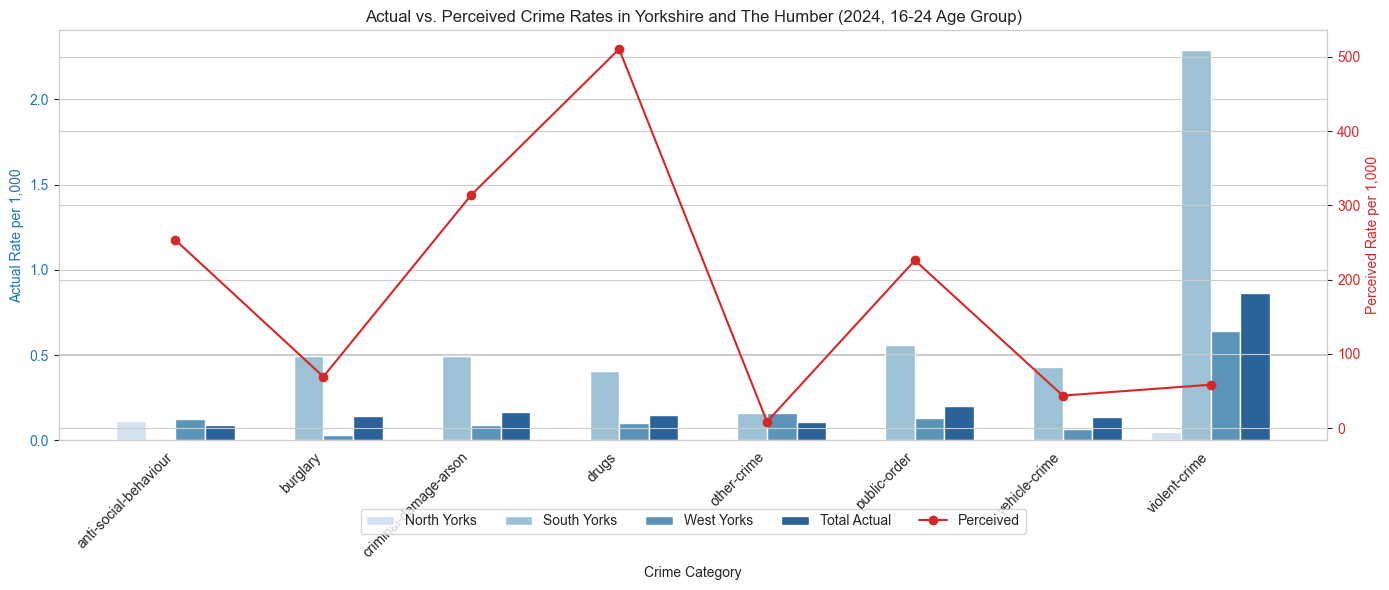


Comparison of Actual and Perceived Crime Rates (16-24 Age Group, per 1,000):


,category,actual_per_1000,North Yorkshire,South Yorkshire,West Yorkshire,perceived_per_1000
0,anti-social-behaviour,0.09,0.11,0.00,0.12,253.15
1,burglary,0.14,0.00,0.49,0.03,69.17
2,criminal-damage-arson,0.16,0.01,0.49,0.09,314.00
3,drugs,0.15,0.01,0.41,0.10,510.53
4,other-crime,0.11,0.01,0.16,0.16,8.53
5,public-order,0.20,0.01,0.56,0.13,225.90
6,vehicle-crime,0.14,0.00,0.43,0.07,43.67
7,violent-crime,0.87,0.05,2.29,0.64,58.33


In [34]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Process the actual crime data (yorkshire_crime_2024.csv)
# Load the actual crime data
actual_crime_data = pd.read_csv('yorkshire_crime_2024.csv')

# Total population of Yorkshire and The Humber (approx. 5.5 million)
total_population = 5_500_000
pop_per_thousand = total_population / 1000  # 5,500

# Approximate population per force (adjust if exact figures available)
force_populations = {
    'South Yorkshire': 1_400_000 / 1000,  # 1.4M
    'West Yorkshire': 2_300_000 / 1000,   # 2.3M
    'North Yorkshire': 1_800_000 / 1000   # 1.8M
}

# Calculate total crimes and rate per 1,000 per category
crime_counts_total = actual_crime_data.groupby('category').size().reset_index(name='total_count')
crime_counts_total['actual_per_1000'] = crime_counts_total['total_count'] / pop_per_thousand

# Calculate crimes per force and rate per 1,000 per force
crime_by_force = actual_crime_data.groupby(['force_name', 'category']).size().reset_index(name='count')
for force, pop in force_populations.items():
    crime_by_force.loc[crime_by_force['force_name'] == force, 'rate_per_1000'] = crime_by_force['count'] / pop

# Pivot for grouped bars
crime_pivot = crime_by_force.pivot(index='category', columns='force_name', values='rate_per_1000').reset_index()
crime_pivot = crime_pivot.fillna(0)
crime_pivot = pd.merge(crime_pivot, crime_counts_total[['category', 'actual_per_1000']], on='category')

# Step 2: Process the perceived crime data (Perceptions_Data_Yorkshire.csv)
# Load the perception data
perception_data = pd.read_csv('Perceptions_Data_Yorkshire.csv')

# Filter for 2024 and 16-24 age group
perception_2024 = perception_data[(perception_data['Year'] == 2024) & (perception_data['Age'] == '16-24')]

# Convert 'Estimate' to numeric by removing '%' and converting to float
perception_2024['Estimate'] = perception_2024['Estimate'].str.rstrip('%').astype(float)

# Combine anti-social-behaviour sub-categories by averaging their estimates
asb_categories = perception_2024[perception_2024['CrimeCategory'].str.contains('anti-social-behaviour', na=False)]['CrimeCategory'].unique()
asb_data = perception_2024[perception_2024['CrimeCategory'].isin(asb_categories)]
asb_avg = asb_data.groupby('Age')['Estimate'].mean().reset_index()
asb_avg['CrimeCategory'] = 'anti-social-behaviour'

# Filter out anti-social-behaviour sub-categories and append the combined one
other_categories = perception_2024[~perception_2024['CrimeCategory'].str.contains('anti-social-behaviour', na=False)]
perception_cleaned = pd.concat([other_categories, asb_avg], ignore_index=True)

# Filter for shared categories
shared_categories = ['anti-social-behaviour', 'burglary', 'criminal-damage-arson', 'drugs', 'other-crime', 'public-order', 'vehicle-crime', 'violent-crime']
perception_cleaned = perception_cleaned[perception_cleaned['CrimeCategory'].isin(shared_categories)]

# Group by CrimeCategory to ensure single estimate per category
perception_grouped = perception_cleaned.groupby('CrimeCategory')['Estimate'].mean().reset_index()
perception_grouped.columns = ['category', 'perceived_percentage']

# Convert perceived percentage to per 1,000 (1% = 10 per 1,000)
perception_grouped['perceived_per_1000'] = perception_grouped['perceived_percentage'] * 10

# Step 3: Merge actual and perceived data
comparison_data = pd.merge(crime_pivot, perception_grouped[['category', 'perceived_per_1000']], on='category', how='inner')

# Step 4: Prepare data for grouped bars
# Melt the data for plotting
melted_data = pd.melt(comparison_data, id_vars=['category'], 
                      value_vars=['North Yorkshire', 'South Yorkshire', 'West Yorkshire', 'actual_per_1000', 'perceived_per_1000'],
                      var_name='metric', value_name='rate_per_1000')
melted_data['metric'] = melted_data['metric'].map({
    'North Yorkshire': 'North Yorks',
    'South Yorkshire': 'South Yorks',
    'West Yorkshire': 'West Yorks',
    'actual_per_1000': 'Total Actual',
    'perceived_per_1000': 'Perceived'
})

# Step 5: Create dual-axis plot
# Set seaborn style
sns.set_style("whitegrid")

# Create figure and axis objects with a single subplot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot grouped bars for actual crimes per 1,000 (excluding perceived for now)
sns.barplot(x='category', y='rate_per_1000', hue='metric', data=melted_data[melted_data['metric'] != 'Perceived'],
            ax=ax1, palette='Blues')
ax1.set_xlabel('Crime Category')
ax1.set_ylabel('Actual Rate per 1,000', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(range(len(comparison_data['category'])))
ax1.set_xticklabels(comparison_data['category'], rotation=45, ha='right')

# Create a second y-axis for the perceived crimes
ax2 = ax1.twinx()
# Plot line for perceived crimes
ax2.plot(comparison_data['category'], comparison_data['perceived_per_1000'], color='tab:red', marker='o', label='Perceived')
ax2.set_ylabel('Perceived Rate per 1,000', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Add title and combined legend
plt.title('Actual vs. Perceived Crime Rates in Yorkshire and The Humber (2024, 16-24 Age Group)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
plt.tight_layout()

# Save the plot
plt.savefig('crime_comparison_grouped_bars.png')
plt.show()

# Step 6: Display the comparison table
print("\nComparison of Actual and Perceived Crime Rates (16-24 Age Group, per 1,000):")
comparison_data['actual_per_1000'] = comparison_data['actual_per_1000'].round(2)
comparison_data['North Yorkshire'] = comparison_data['North Yorkshire'].round(2)
comparison_data['South Yorkshire'] = comparison_data['South Yorkshire'].round(2)
comparison_data['West Yorkshire'] = comparison_data['West Yorkshire'].round(2)
comparison_data['perceived_per_1000'] = comparison_data['perceived_per_1000'].round(2)
display(comparison_data[['category', 'actual_per_1000', 'North Yorkshire', 'South Yorkshire', 'West Yorkshire', 'perceived_per_1000']])